# Module 6: Dual-Channel Processing Fundamentals

## From One Ear to Two: Spatial Signal Processing

Nature gave us two ears for a reason. With two sensors separated in space, we can determine where sounds come from, separate sources, and reject interference. This module teaches you how to extract spatial information from dual-channel recordings.

You'll learn:
* How phase differences encode direction
* Cross-correlation and coherence analysis
* Time delay estimation techniques
* Beamforming basics
* Separating local from distant sources
* Building direction-finding systems

These techniques are fundamental to array processing, radar, sonar, seismology, and radio astronomy.

## Part 1: The Physics of Dual-Channel Sensing

### How Two Sensors See Direction

When a wave arrives at an angle to a sensor pair, it reaches one sensor before the other. This time delay τ creates a phase difference that depends on frequency:

$$phi(f) = -2pi f tau$$

For sensors separated by distance d and a wave arriving at angle θ:

$$tau = frac{d sin(θ)}{c}$$

where c is the wave propagation speed.

Let's visualize this fundamental concept:

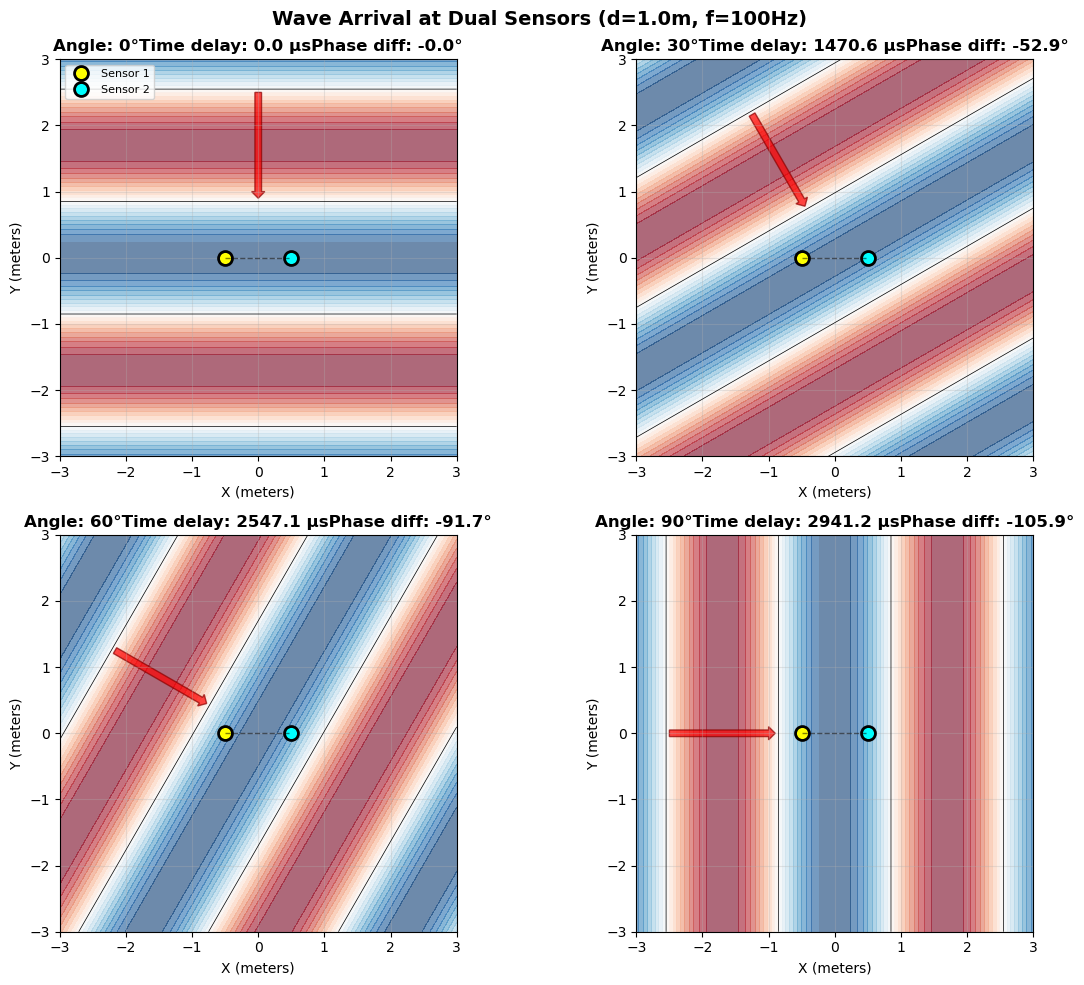

Key observations:
• 0°: Wave arrives simultaneously (no phase difference)
• 30°: Small time delay creates moderate phase shift
• 60°: Larger delay, approaching maximum
• 90°: Maximum delay = d/c (broadside arrival)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrow
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

def wave_arrival_visualization():
    """Visualize how waves arrive at two sensors from different angles."""
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Parameters
    sensor_spacing = 1.0  # meters
    wave_speed = 340  # m/s (sound in air)
    frequency = 100  # Hz
    angles = [0, 30, 60, 90]  # degrees
    
    for idx, angle_deg in enumerate(angles):
        ax = axes[idx // 2, idx % 2]
        
        angle_rad = np.radians(angle_deg)
        
        # Calculate time delay
        time_delay = sensor_spacing * np.sin(angle_rad) / wave_speed
        phase_diff_rad = -2 * np.pi * frequency * time_delay
        phase_diff_deg = np.degrees(phase_diff_rad)
        
        # Create spatial grid
        x = np.linspace(-3, 3, 300)
        y = np.linspace(-3, 3, 300)
        X, Y = np.meshgrid(x, y)
        
        # Wave direction vector
        wave_dir = np.array([np.sin(angle_rad), -np.cos(angle_rad)])
        
        # Calculate wavefronts
        k = 2 * np.pi * frequency / wave_speed  # Wave number
        phase = k * (X * wave_dir[0] + Y * wave_dir[1])
        wave_field = np.cos(phase)
        
        # Plot wavefield
        im = ax.contourf(X, Y, wave_field, levels=20, cmap='RdBu', alpha=0.6)
        ax.contour(X, Y, wave_field, levels=[0], colors='black', linewidths=0.5)
        
        # Plot sensors
        sensor1_pos = [-sensor_spacing/2, 0]
        sensor2_pos = [sensor_spacing/2, 0]
        
        ax.plot(sensor1_pos[0], sensor1_pos[1], 'ko', markersize=10, 
               markerfacecolor='yellow', markeredgewidth=2, label='Sensor 1')
        ax.plot(sensor2_pos[0], sensor2_pos[1], 'ko', markersize=10,
               markerfacecolor='cyan', markeredgewidth=2, label='Sensor 2')
        
        # Draw wave direction arrow
        arrow_start = -2.5 * wave_dir
        arrow = FancyArrow(arrow_start[0], arrow_start[1],
                          1.5*wave_dir[0], 1.5*wave_dir[1],
                          width=0.1, head_width=0.2, head_length=0.1,
                          fc='red', ec='darkred', alpha=0.7)
        ax.add_patch(arrow)
        
        # Add sensor connection
        ax.plot([sensor1_pos[0], sensor2_pos[0]], 
               [sensor1_pos[1], sensor2_pos[1]], 
               'k--', linewidth=1, alpha=0.5)
        
        # Formatting
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X (meters)')
        ax.set_ylabel('Y (meters)')
        
        # Title with calculated values
        ax.set_title(f'Angle: {angle_deg}°'
                    f'Time delay: {time_delay*1e6:.1f} μs'
                    f'Phase diff: {phase_diff_deg:.1f}°',
                    fontweight='bold')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8)
    
    plt.suptitle(f'Wave Arrival at Dual Sensors (d={sensor_spacing}m, f={frequency}Hz)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key observations:")
    print("• 0°: Wave arrives simultaneously (no phase difference)")
    print("• 30°: Small time delay creates moderate phase shift")
    print("• 60°: Larger delay, approaching maximum")
    print("• 90°: Maximum delay = d/c (broadside arrival)")

wave_arrival_visualization()

## Part 2: Cross-Spectral Analysis

### The Cross-Power Spectrum

The cross-power spectrum between two signals reveals their phase relationship at each frequency:

$$S_{xy}(f) = X(f) cdot Y^*(f)$$

Key quantities:
- **Magnitude**: |S_{xy}| - How much power is shared
- **Phase**: ∠S_{xy} - Phase difference between channels
- **Coherence**: |S_{xy}|² / (S_{xx}·S_{yy}) - Correlation at each frequency

Let's implement comprehensive cross-spectral analysis:

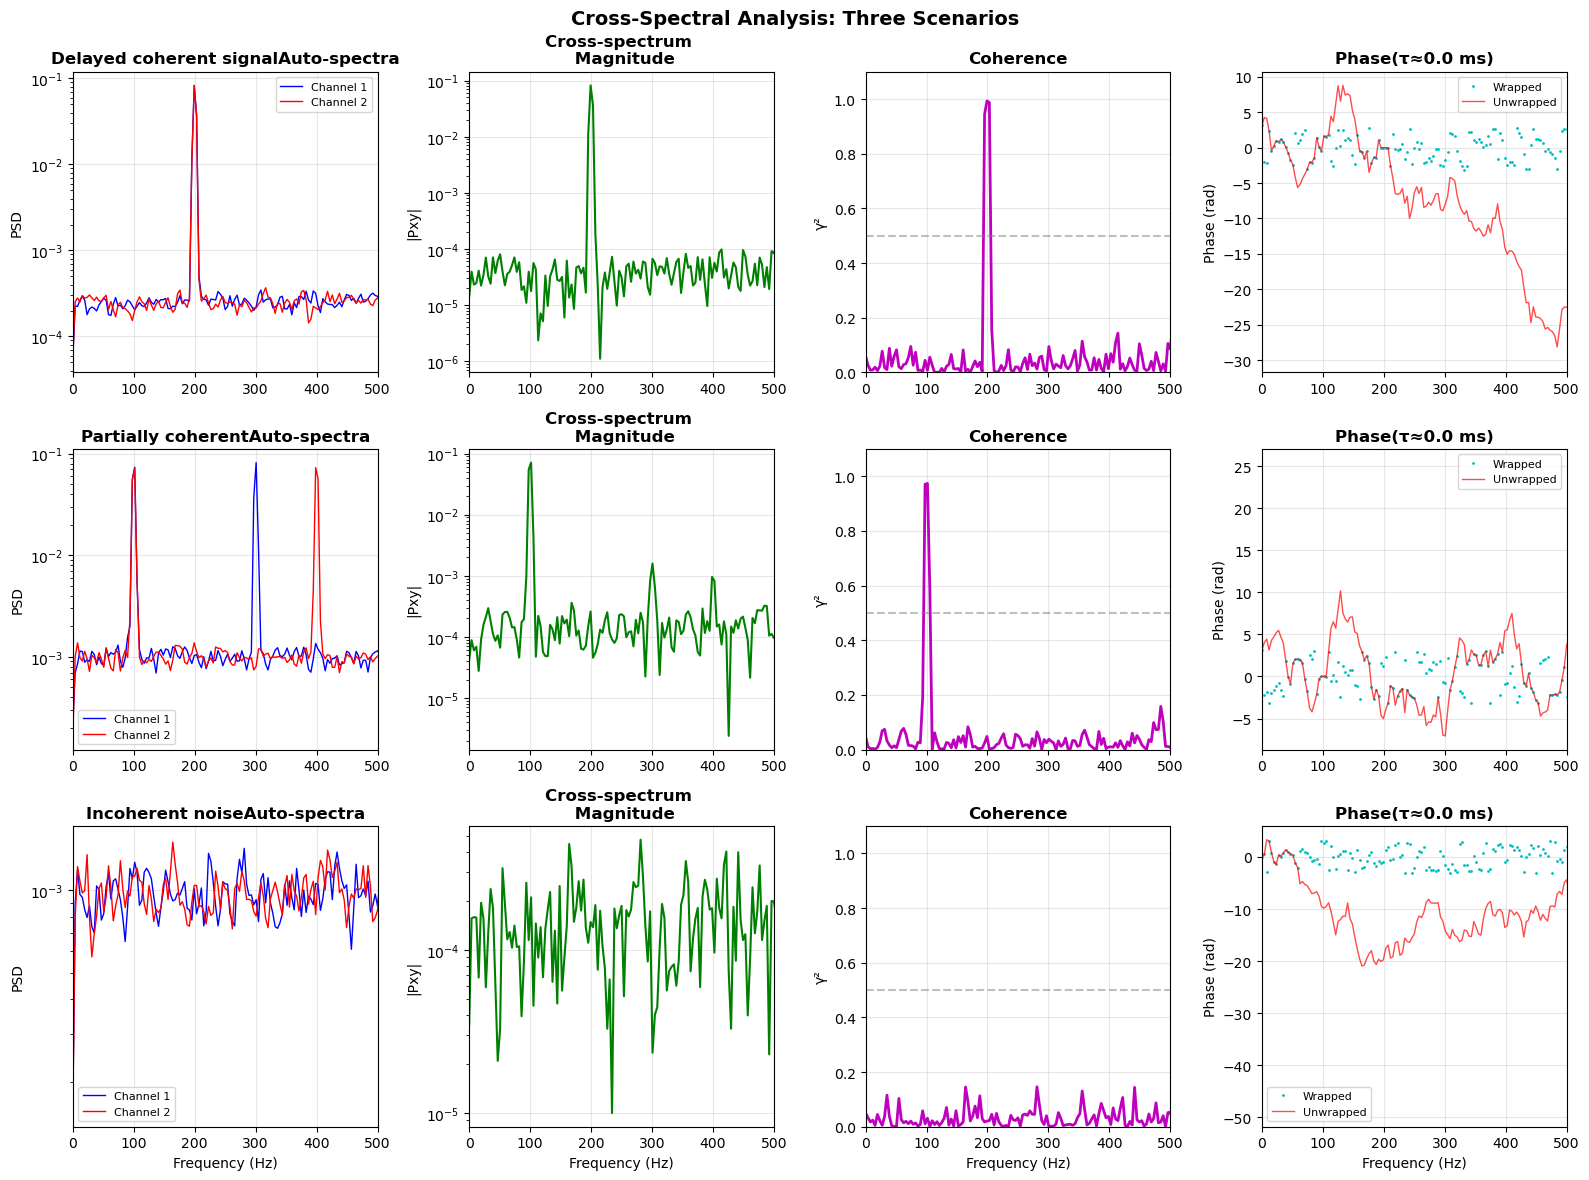

Analysis Summary:
1. Delayed coherent: High coherence, linear phase → measurable delay
2. Partially coherent: Coherence only at shared frequencies
3. Incoherent: Low coherence everywhere, random phase


In [2]:
from scipy import signal

class CrossSpectralAnalyzer:
    """Complete cross-spectral analysis toolkit."""
    
    def __init__(self, fs, nperseg=1024, noverlap=None):
        self.fs = fs
        self.nperseg = nperseg
        self.noverlap = noverlap if noverlap else nperseg // 2
    
    def compute_cross_spectrum(self, x, y):
        """Compute cross-power spectrum and related quantities."""
        
        # Auto-spectra
        f, Pxx = signal.welch(x, self.fs, nperseg=self.nperseg, 
                             noverlap=self.noverlap)
        _, Pyy = signal.welch(y, self.fs, nperseg=self.nperseg,
                             noverlap=self.noverlap)
        
        # Cross-spectrum
        _, Pxy = signal.csd(x, y, self.fs, nperseg=self.nperseg,
                           noverlap=self.noverlap)
        
        # Coherence
        coherence = np.abs(Pxy)**2 / (Pxx * Pyy + 1e-10)
        
        # Phase
        phase = np.angle(Pxy)
        
        # Phase unwrapping for cleaner visualization
        phase_unwrapped = np.unwrap(phase)
        
        # Time delay estimation from phase slope
        # Linear fit to unwrapped phase
        mask = coherence > 0.5  # Only use coherent frequencies
        if np.sum(mask) > 10:
            p = np.polyfit(f[mask], phase_unwrapped[mask], 1)
            time_delay = -p[0] / (2 * np.pi)
        else:
            time_delay = 0
        
        return {
            'frequency': f,
            'Pxx': Pxx,
            'Pyy': Pyy,
            'Pxy': Pxy,
            'coherence': coherence,
            'phase': phase,
            'phase_unwrapped': phase_unwrapped,
            'time_delay': time_delay
        }
    
    def estimate_snr(self, results, signal_band, noise_band):
        """Estimate SNR from cross-spectral results."""
        
        f = results['frequency']
        
        # Signal power (where coherence is high)
        signal_mask = (f >= signal_band[0]) & (f <= signal_band[1])
        signal_coherence = np.mean(results['coherence'][signal_mask])
        
        # Noise (where coherence is low)
        noise_mask = (f >= noise_band[0]) & (f <= noise_band[1])
        noise_coherence = np.mean(results['coherence'][noise_mask])
        
        # SNR estimate
        snr = signal_coherence / (noise_coherence + 1e-10)
        snr_db = 10 * np.log10(snr)
        
        return snr_db


def test_cross_spectral_analysis():
    """Test cross-spectral analysis with various signals."""
    
    fs = 2000
    duration = 5.0
    t = np.arange(0, duration, 1/fs)
    
    # Create test scenarios
    scenarios = []
    
    # Scenario 1: Coherent signal with time delay
    delay_samples = 10
    signal_common = np.sin(2 * np.pi * 200 * t)
    x1 = signal_common + 0.5 * np.random.randn(len(t))
    y1 = np.roll(signal_common, delay_samples) + 0.5 * np.random.randn(len(t))
    scenarios.append((x1, y1, 'Delayed coherent signal'))
    
    # Scenario 2: Partially coherent signals
    x2 = (np.sin(2 * np.pi * 100 * t) + 
         np.sin(2 * np.pi * 300 * t) +
         np.random.randn(len(t)))
    y2 = (np.sin(2 * np.pi * 100 * t) +  # Common component
         np.sin(2 * np.pi * 400 * t) +  # Different component
         np.random.randn(len(t)))
    scenarios.append((x2, y2, 'Partially coherent'))
    
    # Scenario 3: Incoherent (independent) signals
    x3 = np.random.randn(len(t))
    y3 = np.random.randn(len(t))
    scenarios.append((x3, y3, 'Incoherent noise'))
    
    # Analyze each scenario
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    analyzer = CrossSpectralAnalyzer(fs, nperseg=512)
    
    for idx, (x, y, title) in enumerate(scenarios):
        results = analyzer.compute_cross_spectrum(x, y)
        
        # Plot auto-spectra
        axes[idx, 0].semilogy(results['frequency'], results['Pxx'], 'b-', 
                             linewidth=1, label='Channel 1')
        axes[idx, 0].semilogy(results['frequency'], results['Pyy'], 'r-',
                             linewidth=1, label='Channel 2')
        axes[idx, 0].set_title(f'{title}Auto-spectra', fontweight='bold')
        axes[idx, 0].set_ylabel('PSD')
        axes[idx, 0].legend(fontsize=8)
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].set_xlim(0, 500)
        
        # Plot cross-spectrum magnitude
        axes[idx, 1].semilogy(results['frequency'], np.abs(results['Pxy']),
                             'g-', linewidth=1.5)
        axes[idx, 1].set_title('Cross-spectrum n Magnitude', fontweight='bold')
        axes[idx, 1].set_ylabel('|Pxy|')
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_xlim(0, 500)
        
        # Plot coherence
        axes[idx, 2].plot(results['frequency'], results['coherence'],
                         'm-', linewidth=2)
        axes[idx, 2].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        axes[idx, 2].set_title('Coherence', fontweight='bold')
        axes[idx, 2].set_ylabel('γ²')
        axes[idx, 2].set_ylim(0, 1.1)
        axes[idx, 2].grid(True, alpha=0.3)
        axes[idx, 2].set_xlim(0, 500)
        
        # Plot phase
        axes[idx, 3].plot(results['frequency'], results['phase'], 'c.',
                         markersize=2, label='Wrapped')
        axes[idx, 3].plot(results['frequency'], results['phase_unwrapped'],
                         'r-', linewidth=1, alpha=0.7, label='Unwrapped')
        axes[idx, 3].set_title(f'Phase(τ≈{results["time_delay"]*1e3:.1f} ms)',
                              fontweight='bold')
        axes[idx, 3].set_ylabel('Phase (rad)')
        axes[idx, 3].legend(fontsize=8)
        axes[idx, 3].grid(True, alpha=0.3)
        axes[idx, 3].set_xlim(0, 500)
        
        if idx == 2:
            axes[idx, 0].set_xlabel('Frequency (Hz)')
            axes[idx, 1].set_xlabel('Frequency (Hz)')
            axes[idx, 2].set_xlabel('Frequency (Hz)')
            axes[idx, 3].set_xlabel('Frequency (Hz)')
    
    plt.suptitle('Cross-Spectral Analysis: Three Scenarios', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Analysis Summary:")
    print("1. Delayed coherent: High coherence, linear phase → measurable delay")
    print("2. Partially coherent: Coherence only at shared frequencies")
    print("3. Incoherent: Low coherence everywhere, random phase")

test_cross_spectral_analysis()

## Part 3: Time Delay Estimation Methods

### Advanced TDOA Techniques

Time Difference of Arrival (TDOA) is fundamental to localization. Different methods have different strengths:

1. **Cross-correlation**: Find peak in time domain
2. **Phase slope**: Fit line to cross-spectral phase
3. **Generalized Cross-Correlation (GCC)**: Weighted cross-correlation
4. **MUSIC algorithm**: Super-resolution technique

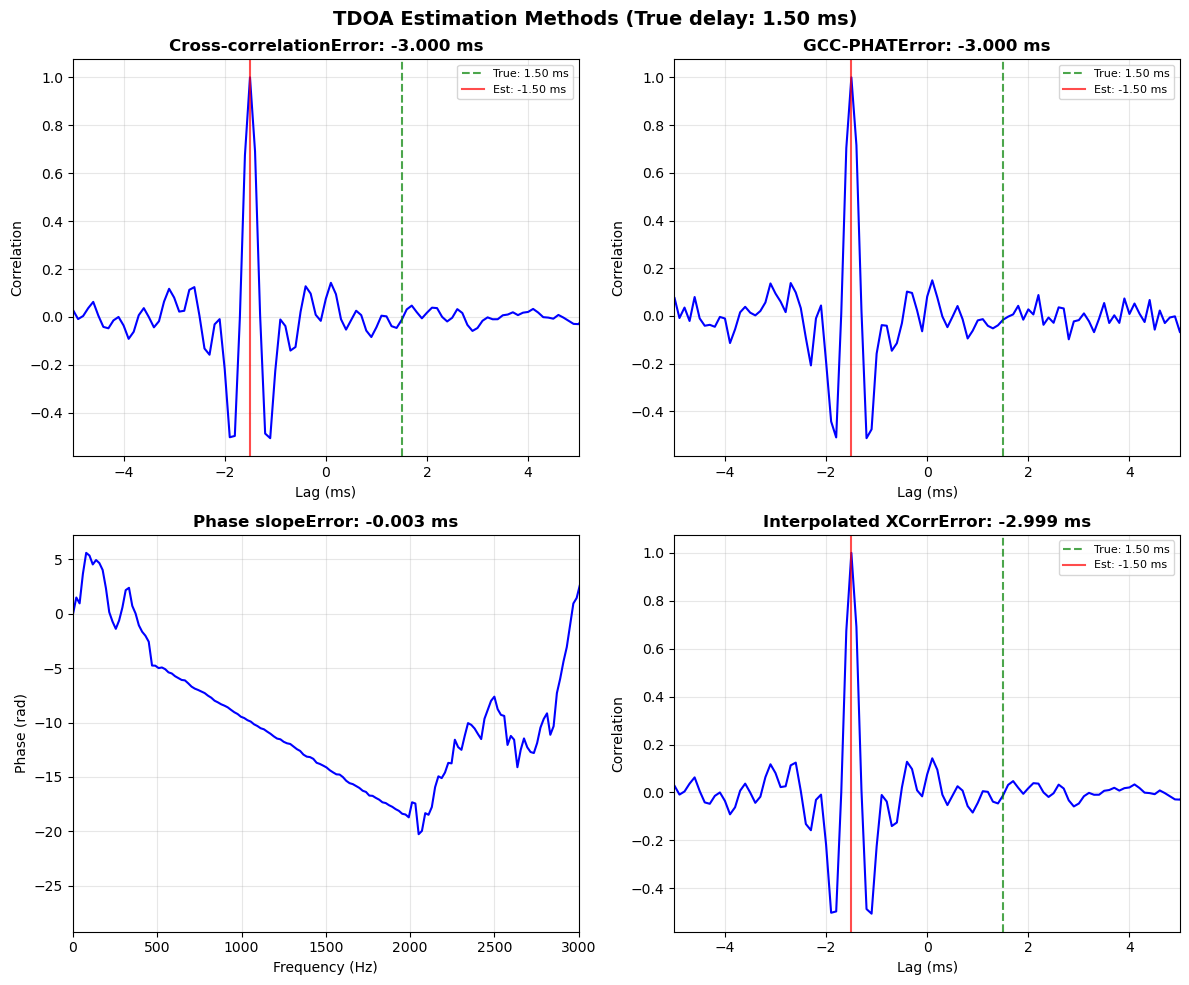

Method Comparison:
Cross-correlation   :  -1.500 ms (error: -3.000 ms)
GCC-PHAT            :  -1.500 ms (error: -3.000 ms)
Phase slope         :   1.497 ms (error: -0.003 ms)
Interpolated XCorr  :  -1.499 ms (error: -2.999 ms)
Method characteristics:
• Cross-correlation: Simple, works well for broadband signals
• GCC-PHAT: Robust to reverberation, sharp peaks
• Phase slope: Best for narrowband, sensitive to noise
• Interpolated: Sub-sample precision, good for high SNR


In [3]:
from scipy.signal import correlate
from scipy.optimize import minimize_scalar

def tdoa_comparison():
    """Compare different TDOA estimation methods."""
    
    # Generate test signal with known delay
    fs = 10000
    duration = 1.0
    t = np.arange(0, duration, 1/fs)
    
    # True delay
    true_delay = 0.0015  # 1.5 ms
    delay_samples = int(true_delay * fs)
    
    # Create signal: chirp + noise
    chirp = signal.chirp(t, f0=500, f1=2000, t1=duration, method='linear')
    noise_level = 0.5
    
    x = chirp + noise_level * np.random.randn(len(t))
    y = np.roll(chirp, delay_samples) + noise_level * np.random.randn(len(t))
    
    # Method 1: Cross-correlation
    def xcorr_tdoa(x, y, fs):
        """Standard cross-correlation TDOA."""
        corr = correlate(x, y, mode='same')
        lags = np.arange(-len(x)//2, len(x)//2) / fs
        peak_idx = np.argmax(np.abs(corr))
        return lags[peak_idx], corr, lags
    
    # Method 2: GCC-PHAT (Phase Transform)
    def gcc_phat_tdoa(x, y, fs):
        """Generalized Cross-Correlation with Phase Transform."""
        # FFT
        X = np.fft.rfft(x)
        Y = np.fft.rfft(y)
        
        # Cross-spectrum
        G = X * np.conj(Y)
        
        # PHAT weighting
        W = 1 / (np.abs(G) + 1e-10)
        G_phat = G * W
        
        # Inverse FFT to get correlation
        gcc = np.fft.irfft(G_phat)
        gcc = np.concatenate([gcc[len(gcc)//2:], gcc[:len(gcc)//2]])
        
        lags = np.arange(-len(gcc)//2, len(gcc)//2) / fs
        peak_idx = np.argmax(np.abs(gcc))
        
        return lags[peak_idx], gcc, lags
    
    # Method 3: Phase slope fitting
    def phase_slope_tdoa(x, y, fs):
        """TDOA from cross-spectral phase slope."""
        f, Pxy = signal.csd(x, y, fs, nperseg=512)
        
        # Coherence for weighting
        _, Pxx = signal.welch(x, fs, nperseg=512)
        _, Pyy = signal.welch(y, fs, nperseg=512)
        coherence = np.abs(Pxy)**2 / (Pxx * Pyy + 1e-10)
        
        # Use only coherent frequencies
        mask = coherence > 0.5
        if np.sum(mask) > 10:
            phase = np.unwrap(np.angle(Pxy))
            # Weighted linear fit
            weights = coherence[mask]
            p = np.polyfit(f[mask], phase[mask], 1, w=weights)
            delay = -p[0] / (2 * np.pi)
        else:
            delay = 0
            phase = np.angle(Pxy)
        
        return delay, phase, f
    
    # Method 4: Interpolated correlation peak
    def interpolated_xcorr_tdoa(x, y, fs):
        """Sub-sample TDOA using parabolic interpolation."""
        corr = correlate(x, y, mode='same')
        peak_idx = np.argmax(np.abs(corr))
        
        # Parabolic interpolation around peak
        if 1 <= peak_idx < len(corr) - 1:
            y1 = np.abs(corr[peak_idx - 1])
            y2 = np.abs(corr[peak_idx])
            y3 = np.abs(corr[peak_idx + 1])
            
            # Parabolic peak offset
            offset = 0.5 * (y1 - y3) / (y1 - 2*y2 + y3 + 1e-10)
            
            # Refined delay
            delay = (peak_idx + offset - len(corr)//2) / fs
        else:
            delay = (peak_idx - len(corr)//2) / fs
        
        lags = np.arange(-len(corr)//2, len(corr)//2) / fs
        return delay, corr, lags
    
    # Run all methods
    methods = [
        ('Cross-correlation', xcorr_tdoa),
        ('GCC-PHAT', gcc_phat_tdoa),
        ('Phase slope', phase_slope_tdoa),
        ('Interpolated XCorr', interpolated_xcorr_tdoa)
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    results = []
    
    for idx, (name, method) in enumerate(methods):
        ax = axes[idx]
        
        # Estimate delay
        if name == 'Phase slope':
            delay_est, data, x_axis = method(x, y, fs)
            ax.plot(x_axis, data, 'b-', linewidth=1.5)
            ax.set_xlabel('Frequency (Hz)')
            ax.set_ylabel('Phase (rad)')
            ax.set_xlim(0, 3000)
        else:
            delay_est, data, x_axis = method(x, y, fs)
            ax.plot(x_axis * 1000, data / np.max(np.abs(data)), 
                   'b-', linewidth=1.5)
            ax.axvline(true_delay * 1000, color='green', linestyle='--',
                      alpha=0.7, label=f'True: {true_delay*1000:.2f} ms')
            ax.axvline(delay_est * 1000, color='red', linestyle='-',
                      alpha=0.7, label=f'Est: {delay_est*1000:.2f} ms')
            ax.set_xlabel('Lag (ms)')
            ax.set_ylabel('Correlation')
            ax.set_xlim(-5, 5)
        
        error = (delay_est - true_delay) * 1000  # ms
        results.append((name, delay_est * 1000, error))
        
        ax.set_title(f'{name}Error: {error:.3f} ms', fontweight='bold')
        ax.grid(True, alpha=0.3)
        if idx != 2:
            ax.legend(fontsize=8)
    
    plt.suptitle(f'TDOA Estimation Methods (True delay: {true_delay*1000:.2f} ms)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print comparison
    print("Method Comparison:")
    print("="*50)
    for name, est, error in results:
        print(f"{name:20s}: {est:7.3f} ms (error: {error:+.3f} ms)")
    
    print("Method characteristics:")
    print("• Cross-correlation: Simple, works well for broadband signals")
    print("• GCC-PHAT: Robust to reverberation, sharp peaks")
    print("• Phase slope: Best for narrowband, sensitive to noise")
    print("• Interpolated: Sub-sample precision, good for high SNR")

tdoa_comparison()

## Part 4: Introduction to Beamforming

### Spatial Filtering with Two Sensors

Beamforming combines signals from multiple sensors to enhance signals from specific directions while suppressing others. With just two sensors, we can create simple beams:

In [4]:
from ipywidgets import interact, FloatSlider

def dual_channel_beamforming(steering_angle, null_angle):
    """Interactive beamforming demonstration."""
    
    # System parameters
    fs = 10000
    duration = 0.5
    t = np.arange(0, duration, 1/fs)
    
    # Array geometry
    d = 0.5  # meters (sensor spacing)
    c = 340  # m/s (wave speed)
    
    # Source signals from different directions
    angles = np.array([30, -45, 0, 60])  # degrees
    frequencies = np.array([500, 800, 1200, 300])  # Hz
    amplitudes = np.array([1.0, 0.8, 0.6, 0.7])
    
    # Generate array signals
    x1 = np.zeros_like(t)
    x2 = np.zeros_like(t)
    
    for angle, freq, amp in zip(angles, frequencies, amplitudes):
        angle_rad = np.radians(angle)
        delay = d * np.sin(angle_rad) / c
        
        # Signal at sensor 1
        s1 = amp * np.sin(2 * np.pi * freq * t)
        # Signal at sensor 2 (with delay)
        s2 = amp * np.sin(2 * np.pi * freq * (t - delay))
        
        x1 += s1
        x2 += s2
    
    # Add noise
    x1 += 0.1 * np.random.randn(len(t))
    x2 += 0.1 * np.random.randn(len(t))
    
    # Beamforming weights
    def compute_weights(angle_deg, null_deg=None):
        """Compute beamforming weights for steering and null."""
        angle_rad = np.radians(angle_deg)
        
        # Basic delay-and-sum weights
        freqs = np.fft.rfftfreq(1024, 1/fs)
        delays = d * np.sin(angle_rad) / c
        
        # Frequency-dependent weights
        weights = np.exp(1j * 2 * np.pi * freqs * delays)
        
        if null_deg is not None:
            # Add null constraint
            null_rad = np.radians(null_deg)
            null_delay = d * np.sin(null_rad) / c
            null_weights = np.exp(1j * 2 * np.pi * freqs * null_delay)
            
            # Null-steering (simplified)
            weights = weights - 0.5 * null_weights
        
        return weights
    
    # Apply beamforming
    weights = compute_weights(steering_angle, null_angle)
    
    # Process in frequency domain
    X1 = np.fft.rfft(x1[:1024])
    X2 = np.fft.rfft(x2[:1024])
    
    # Beamformed output
    Y_beam = X1 + weights * X2
    y_beam = np.fft.irfft(Y_beam)
    
    # Compute beam pattern
    test_angles = np.linspace(-90, 90, 180)
    beam_pattern = []
    
    for test_angle in test_angles:
        w = compute_weights(test_angle, null_angle)
        response = np.mean(np.abs(1 + w)**2)
        beam_pattern.append(response)
    
    beam_pattern = np.array(beam_pattern)
    beam_pattern_db = 10 * np.log10(beam_pattern / np.max(beam_pattern) + 1e-10)
    
    # Visualization
    fig = plt.figure(figsize=(14, 8))
    
    # Beam pattern (polar plot)
    ax1 = plt.subplot(121, projection='polar')
    theta = np.radians(test_angles)
    ax1.plot(theta, beam_pattern_db + 40, 'b-', linewidth=2)
    ax1.fill_between(theta, -40, beam_pattern_db + 40, alpha=0.3)
    ax1.set_ylim(-40, 0)
    ax1.set_theta_zero_location('N')
    ax1.set_title('Beam Pattern', fontweight='bold', pad=20)
    
    # Mark steering direction
    ax1.plot(np.radians(steering_angle), 0, 'go', markersize=10,
            label=f'Steering: {steering_angle}°')
    if null_angle is not None:
        ax1.plot(np.radians(null_angle), 0, 'ro', markersize=10,
                label=f'Null: {null_angle}°')
    
    # Mark source locations
    for angle in angles:
        ax1.plot(np.radians(angle), -5, 'k*', markersize=8)
    
    ax1.legend(loc='upper left', bbox_to_anchor=(1.1, 1))
    
    # Spectrograms
    ax2 = plt.subplot(322)
    f, t_spec, Sxx1 = signal.spectrogram(x1, fs, nperseg=256)
    ax2.pcolormesh(t_spec, f, 10*np.log10(Sxx1+1e-10), 
                  shading='gouraud', cmap='viridis')
    ax2.set_title('Channel 1 Input', fontweight='bold')
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_ylim(0, 1500)
    
    ax3 = plt.subplot(324)
    f, t_spec, Sxx2 = signal.spectrogram(x2, fs, nperseg=256)
    ax3.pcolormesh(t_spec, f, 10*np.log10(Sxx2+1e-10),
                  shading='gouraud', cmap='viridis')
    ax3.set_title('Channel 2 Input', fontweight='bold')
    ax3.set_ylabel('Frequency (Hz)')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylim(0, 1500)
    
    ax4 = plt.subplot(326)
    # Extend beamformed output for spectrogram
    y_beam_extended = np.tile(y_beam, int(np.ceil(len(x1)/len(y_beam))))[:len(x1)]
    f, t_spec, Sxx_beam = signal.spectrogram(y_beam_extended, fs, nperseg=256)
    ax4.pcolormesh(t_spec, f, 10*np.log10(Sxx_beam+1e-10),
                  shading='gouraud', cmap='viridis')
    ax4.set_title('Beamformed Output', fontweight='bold')
    ax4.set_ylabel('Frequency (Hz)')
    ax4.set_xlabel('Time (s)')
    ax4.set_ylim(0, 1500)
    
    plt.suptitle(f'Dual-Channel Beamforming (Steering: {steering_angle}°, Null: {null_angle}°)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print source information
    print("Source locations:")
    for angle, freq in zip(angles, frequencies):
        print(f"  {angle:+3.0f}°: {freq:4.0f} Hz")

interact(dual_channel_beamforming,
         steering_angle=FloatSlider(value=30, min=-90, max=90, step=5,
                                   description='Steer (°)'),
         null_angle=FloatSlider(value=-45, min=-90, max=90, step=5,
                               description='Null (°)'))

interactive(children=(FloatSlider(value=30.0, description='Steer (°)', max=90.0, min=-90.0, step=5.0), FloatSl…

<function __main__.dual_channel_beamforming(steering_angle, null_angle)>

## Part 5: Distinguishing Local vs Distant Sources

### The Near-Field / Far-Field Problem

Local interference (near-field) and distant signals (far-field) have different characteristics:
- **Far-field**: Plane waves, constant phase difference across frequencies
- **Near-field**: Spherical waves, frequency-dependent phase
- **Local interference**: Often coupled equally into both channels

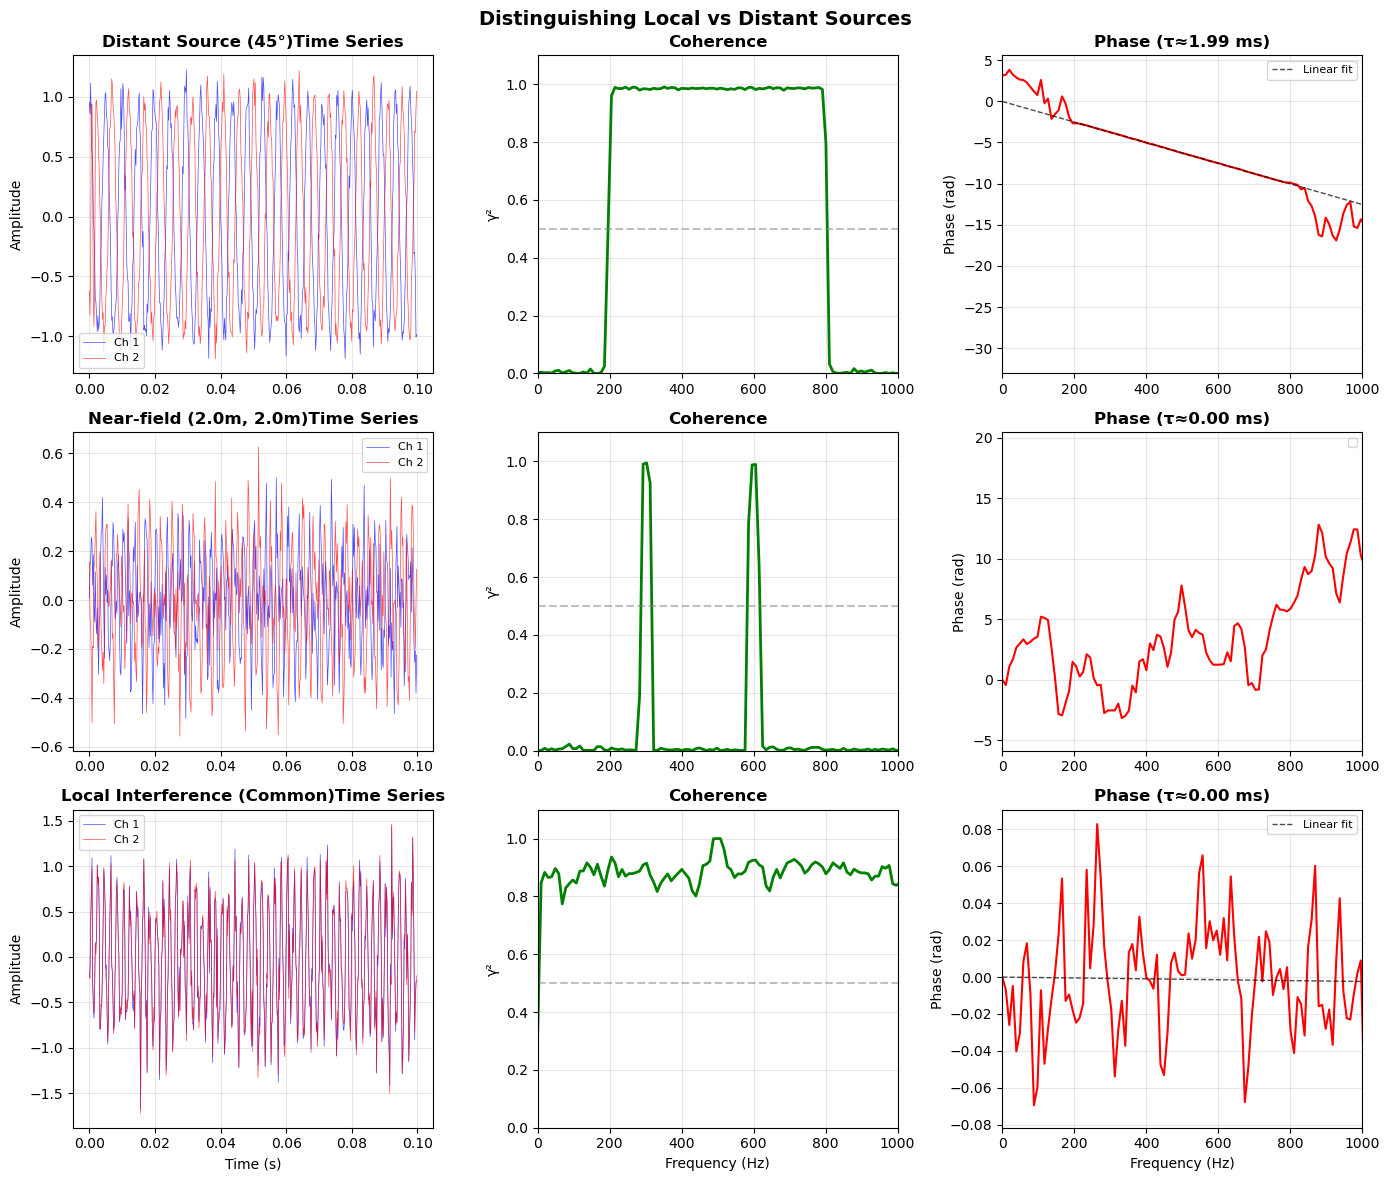

Characteristic signatures:
1. DISTANT SOURCE:
   • High coherence at signal frequencies
   • Linear phase relationship (constant delay)
   • Equal amplitudes on both channels
2. NEAR-FIELD SOURCE:
   • Moderate coherence
   • Slightly curved phase (frequency-dependent delay)
   • Different amplitudes (1/r falloff)
3. LOCAL INTERFERENCE:
   • Very high coherence (>0.9)
   • Zero or constant phase difference
   • Nearly identical waveforms


In [5]:
def local_vs_distant_analysis():
    """Analyze characteristics of local vs distant sources."""
    
    fs = 5000
    duration = 2.0
    t = np.arange(0, duration, 1/fs)
    
    # Array parameters
    d = 1.0  # sensor separation (meters)
    c = 340  # wave speed
    
    # Create three types of sources
    sources = []
    
    # 1. Distant source (plane wave)
    distant_angle = 45  # degrees
    distant_delay = d * np.sin(np.radians(distant_angle)) / c
    distant_sig = signal.chirp(t, f0=200, f1=800, t1=duration)
    
    x1_distant = distant_sig + 0.1 * np.random.randn(len(t))
    x2_distant = np.roll(distant_sig, int(distant_delay * fs)) + 0.1 * np.random.randn(len(t))
    sources.append((x1_distant, x2_distant, 'Distant Source (45°)'))
    
    # 2. Near-field source
    source_x, source_y = 2.0, 2.0  # meters
    r1 = np.sqrt((source_x + d/2)**2 + source_y**2)
    r2 = np.sqrt((source_x - d/2)**2 + source_y**2)
    
    # Frequency-dependent delays
    near_sig = 0.5 * (np.sin(2 * np.pi * 300 * t) + 
                     np.sin(2 * np.pi * 600 * t))
    
    # Amplitude falls off with distance
    amp1 = 1 / r1
    amp2 = 1 / r2
    delay_near = (r2 - r1) / c
    
    x1_near = amp1 * near_sig + 0.1 * np.random.randn(len(t))
    x2_near = amp2 * np.roll(near_sig, int(delay_near * fs)) + 0.1 * np.random.randn(len(t))
    sources.append((x1_near, x2_near, f'Near-field ({source_x:.1f}m, {source_y:.1f}m)'))
    
    # 3. Local interference (common mode)
    local_sig = 0.8 * np.sin(2 * np.pi * 500 * t)
    common_noise = 0.3 * np.random.randn(len(t))
    
    x1_local = local_sig + common_noise + 0.05 * np.random.randn(len(t))
    x2_local = local_sig + common_noise + 0.05 * np.random.randn(len(t))
    sources.append((x1_local, x2_local, 'Local Interference (Common)'))
    
    # Analyze each source type
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    
    analyzer = CrossSpectralAnalyzer(fs, nperseg=512)
    
    for idx, (x1, x2, title) in enumerate(sources):
        results = analyzer.compute_cross_spectrum(x1, x2)
        
        # Time series
        axes[idx, 0].plot(t[:500], x1[:500], 'b-', linewidth=0.5, 
                         alpha=0.7, label='Ch 1')
        axes[idx, 0].plot(t[:500], x2[:500], 'r-', linewidth=0.5,
                         alpha=0.7, label='Ch 2')
        axes[idx, 0].set_title(f'{title}Time Series', fontweight='bold')
        axes[idx, 0].set_ylabel('Amplitude')
        axes[idx, 0].legend(fontsize=8)
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Coherence
        axes[idx, 1].plot(results['frequency'], results['coherence'],
                         'g-', linewidth=2)
        axes[idx, 1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        axes[idx, 1].set_title('Coherence', fontweight='bold')
        axes[idx, 1].set_ylabel('γ²')
        axes[idx, 1].set_ylim(0, 1.1)
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_xlim(0, 1000)
        
        # Phase difference
        axes[idx, 2].plot(results['frequency'], results['phase_unwrapped'],
                         'r-', linewidth=1.5)
        
        # Fit line to phase for far-field check
        mask = results['coherence'] > 0.7
        if np.sum(mask) > 10:
            p = np.polyfit(results['frequency'][mask], 
                         results['phase_unwrapped'][mask], 1)
            fit_line = p[0] * results['frequency'] + p[1]
            axes[idx, 2].plot(results['frequency'], fit_line, 'k--',
                            linewidth=1, alpha=0.7, label='Linear fit')
        
        axes[idx, 2].set_title(f'Phase (τ≈{results["time_delay"]*1e3:.2f} ms)',
                              fontweight='bold')
        axes[idx, 2].set_ylabel('Phase (rad)')
        axes[idx, 2].legend(fontsize=8)
        axes[idx, 2].grid(True, alpha=0.3)
        axes[idx, 2].set_xlim(0, 1000)
        
        if idx == 2:
            axes[idx, 0].set_xlabel('Time (s)')
            axes[idx, 1].set_xlabel('Frequency (Hz)')
            axes[idx, 2].set_xlabel('Frequency (Hz)')
    
    plt.suptitle('Distinguishing Local vs Distant Sources', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Characteristic signatures:")
    print("1. DISTANT SOURCE:")
    print("   • High coherence at signal frequencies")
    print("   • Linear phase relationship (constant delay)")
    print("   • Equal amplitudes on both channels")
    
    print("2. NEAR-FIELD SOURCE:")
    print("   • Moderate coherence")
    print("   • Slightly curved phase (frequency-dependent delay)")
    print("   • Different amplitudes (1/r falloff)")
    
    print("3. LOCAL INTERFERENCE:")
    print("   • Very high coherence (>0.9)")
    print("   • Zero or constant phase difference")
    print("   • Nearly identical waveforms")

local_vs_distant_analysis()

## Module Summary

### Key Concepts

1. **Phase encodes direction**: Time delays create frequency-dependent phase shifts
2. **Coherence reveals correlation**: High coherence indicates common source
3. **Multiple TDOA methods**: Each optimal for different signal types
4. **Beamforming enhances direction**: Even two sensors can spatially filter
5. **Source characteristics differ**: Local/distant sources have distinct signatures

### Quick Reference

```python
# Cross-spectrum
f, Pxy = signal.csd(x, y, fs)
coherence = signal.coherence(x, y, fs)[1]

# Time delay from phase
phase = np.unwrap(np.angle(Pxy))
delay = -np.polyfit(f, phase, 1)[0] / (2*np.pi)

# Direction from delay
angle = np.arcsin(delay * c / d)  # radians

# Basic beamforming
weights = np.exp(1j * 2 * np.pi * f * delay_steer)
output = X1 + weights * X2
```

### Practical Guidelines

**For direction finding:**
- Sensor spacing < λ/2 to avoid ambiguity
- Use GCC-PHAT for reverberant environments
- Calibrate channels for matched gain/phase

**For source separation:**
- High coherence + zero delay = local interference
- Linear phase = far-field source
- Curved phase = near-field source

### What's Next?

The final module (Capstone) will combine everything you've learned to build a complete signal analysis system for complex, real-world scenarios.